# CAA Steering Experiments — Emotion × Intensity

Contrastive Activation Addition (CAA) experiments using steering vectors derived from the
residual stream analysis.

**Steering vectors (layer 13):**
1. `v_emotion[e]` = mean(emotion e) − mean(non-emotion e)  — *OvR emotion direction*
2. `v_intensity`  = mean(high) − mean(low)                 — *global intensity axis*
3. `v_emotion_intensity[e]` = mean(e, high) − mean(e, low) — *emotion-specific intensity*
4. `v_pairwise[A, B]` = mean(emotion A) − mean(emotion B)  — *pairwise CAA direction*

**Key questions:**
- Does +v_joy / +v_sadness / +v_anger shift rewrites toward the target emotion?
- Does ±v_intensity amplify / dampen emotional expression **without** changing category?
- Do pairwise vectors (original CAA) steer more precisely than OvR vectors?
- Is `v_A_vs_B` truly "adding A", or mainly "removing B"?

---

**Sections:**
1. Imports & Configuration
2. Load Steering Vectors
2b. Pairwise CAA Contrast Vectors
3. Load Model & Tokenizer
4. Hook-Based Residual Stream Intervention
5. Emotion Steering Experiments
5b. Pairwise Emotion Steering Experiments
5c. Same Target, Different "Away-From" — Diagnosing Pairwise Direction
6. Global Intensity Steering Experiments
7. Emotion-Specific Intensity Steering
8. Quantitative Evaluation via Re-Probe
9. Steering Strength Sweep (α scaling)
10. Alpha Grid Sweep — All Emotions & Intensities
11. Results Summary & CSV Export

## 1. Imports & Configuration

In [ ]:
from __future__ import annotations

import gc
import json
import warnings
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml

warnings.filterwarnings("ignore", category=UserWarning)

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT  = Path("../..").resolve()
ACT_DIR    = REPO_ROOT / "activation" / "emotion_rewrites"
NPY_PATH   = ACT_DIR / "emotion_intensity_residual_stream.npy"
INFO_PATH  = ACT_DIR / "emotion_intensity_residual_stream_info.json"
OUT_DIR    = REPO_ROOT / "analysis" / "emotion_intensity" / "steering"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Steering configuration ────────────────────────────────────────────────────
STEER_LAYER = 13          # transformer block index (0-based); hooks OUTPUT of this block
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

# Alpha grid for the sweep (section 9)
ALPHA_GRID = [-10, -7, -5, -3, -2, 0, 2, 3, 5, 7, 10]

# Default alpha for qualitative experiments
ALPHA_DEFAULT = 5.0

# Generation settings — greedy decoding to avoid repetition degeneration
MAX_NEW_TOKENS = 40
SEED           = 42

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150})

print(f"Device         : {DEVICE}")
print(f"Steer layer    : {STEER_LAYER}")
print(f"Output dir     : {OUT_DIR}")


Device         : cuda
Steer layer    : 13
Output dir     : /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/steering


## 2. Load Steering Vectors

Re-derive all three vector families from the pre-computed activation file.

$$
\mathbf{v}_e = \bar{\mathbf{h}}_e - \overline{\mathbf{h}}_{\neg e}
\qquad
\mathbf{v}_{\text{int}} = \bar{\mathbf{h}}_{\text{high}} - \bar{\mathbf{h}}_{\text{low}}
\qquad
\mathbf{v}_{\text{int},e} = \bar{\mathbf{h}}_{e,\text{high}} - \bar{\mathbf{h}}_{e,\text{low}}
$$

All vectors are normalized to unit norm; use `alpha` to set scale at steering time.

In [23]:
# ── Load metadata ─────────────────────────────────────────────────────────────
with open(INFO_PATH) as f:
    INFO = json.load(f)

LAYER_INDICES:   list[int] = INFO["layer_indices"]
EMOTION_ORDER:   list[str] = INFO["emotion_order"]
INTENSITY_ORDER: list[str] = INFO["intensity_order"]
SHAPE                      = tuple(INFO["shape"])   # (N, N_EMO, N_INT, N_LAYERS, D)
DTYPE                      = INFO.get("dtype", "float32")

N, N_EMO, N_INT, N_LAYERS, D = SHAPE

# Index of STEER_LAYER in the extracted layer list
LI = LAYER_INDICES.index(STEER_LAYER)

HIGH_IDX = INTENSITY_ORDER.index("high")
MED_IDX  = INTENSITY_ORDER.index("medium")
LOW_IDX  = INTENSITY_ORDER.index("low")

act_file_gb = (N * N_EMO * N_INT * N_LAYERS * D * np.dtype(DTYPE).itemsize) / 1e9
print(f"Tensor shape    : {SHAPE}")
print(f"Act file size   : {act_file_gb:.2f} GB  (memory-mapped, not fully loaded)")
print(f"Layer indices   : {LAYER_INDICES}  →  using index LI={LI} (layer {STEER_LAYER})")
print(f"Emotions        : {EMOTION_ORDER}")
print(f"Intensities     : {INTENSITY_ORDER}  (low={LOW_IDX}, med={MED_IDX}, high={HIGH_IDX})")

# ── Load activations (memory-mapped — never fully materialised in RAM) ─────────
act: np.ndarray = np.memmap(str(NPY_PATH), dtype=DTYPE, mode="r", shape=SHAPE)

# ── Prototype means: accumulate ONLY the single steer layer to save RAM ───────
#    proto_l[e, i, :] = mean_n act[n, e, i, LI, :]
#    Peak RAM: (N_EMO, N_INT, D) float64 ≈ 8*3*4096*8 = 786 KB
print("Computing prototype means for layer", STEER_LAYER, "…")
proto_sum = np.zeros((N_EMO, N_INT, D), dtype=np.float64)
for n in range(N):
    proto_sum += act[n, :, :, LI, :].astype(np.float64)   # (N_EMO, N_INT, D)
proto_l = (proto_sum / N).astype(np.float32)   # (N_EMO, N_INT, D)
del proto_sum
gc.collect()
print(f"proto_l shape   : {proto_l.shape}  (N_EMO, N_INT, D)  RAM ≈ {proto_l.nbytes/1e6:.1f} MB")

# ── Helper ────────────────────────────────────────────────────────────────────
def unit(v: np.ndarray) -> np.ndarray:
    """Normalise last axis to unit L2 norm."""
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + 1e-10)

# ── Vector 1: One-vs-Rest emotion vectors ────────────────────────────────────
emo_mean         = proto_l.mean(axis=1)                                       # (N_EMO, D)
v_emotion_raw    = emo_mean - (emo_mean.sum(axis=0, keepdims=True) - emo_mean) / (N_EMO - 1)
v_emotion        = unit(v_emotion_raw)                                        # (N_EMO, D)

# ── Vector 2: Global intensity direction ─────────────────────────────────────
intensity_dirs_raw = proto_l[:, HIGH_IDX, :] - proto_l[:, LOW_IDX, :]        # (N_EMO, D)
v_intensity_raw    = intensity_dirs_raw.mean(axis=0)                          # (D,)
v_intensity        = unit(v_intensity_raw)                                    # (D,)

# ── Vector 3: Emotion-specific intensity directions ───────────────────────────
v_emotion_intensity_raw = intensity_dirs_raw                                   # (N_EMO, D)
v_emotion_intensity     = unit(v_emotion_intensity_raw)                        # (N_EMO, D)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\nSteering vectors (unit-norm) at layer", STEER_LAYER)
print(f"  {'vector':<30} {'raw norm':>10}")
print("  " + "-" * 42)
for ei, emo in enumerate(EMOTION_ORDER):
    print(f"  v_emotion[{emo:<12}]        {np.linalg.norm(v_emotion_raw[ei]):>10.4f}")
print(f"  v_intensity                    {np.linalg.norm(v_intensity_raw):>10.4f}")
for ei, emo in enumerate(EMOTION_ORDER):
    print(f"  v_emotion_intensity[{emo:<9}] {np.linalg.norm(v_emotion_intensity_raw[ei]):>10.4f}")


Tensor shape    : (22782, 8, 3, 6, 4096)
Act file size   : 53.75 GB  (memory-mapped, not fully loaded)
Layer indices   : [8, 10, 13, 16, 19, 22]  →  using index LI=2 (layer 13)
Emotions        : ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
Intensities     : ['low', 'medium', 'high']  (low=0, med=1, high=2)
Computing prototype means for layer 13 …
proto_l shape   : (8, 3, 4096)  (N_EMO, N_INT, D)  RAM ≈ 0.4 MB

Steering vectors (unit-norm) at layer 13
  vector                           raw norm
  ------------------------------------------
  v_emotion[joy         ]            1.3560
  v_emotion[trust       ]            1.4393
  v_emotion[fear        ]            1.1469
  v_emotion[surprise    ]            1.5238
  v_emotion[sadness     ]            0.9384
  v_emotion[disgust     ]            1.0565
  v_emotion[anger       ]            1.1920
  v_emotion[anticipation]            1.1873
  v_intensity                        1.1805
  v_emotion_intensity

## 2b. Pairwise CAA Contrast Vectors

The original CAA method contrasts the **same** source text at the **same** intensity with
different emotion labels — only the emotion label changes:

$$
\mathbf{v}_{A \to B}
= \frac{1}{N \cdot N_{\mathrm{int}}} \sum_{n,\, i}
  \bigl(\mathbf{h}[n, A, i, \ell] - \mathbf{h}[n, B, i, \ell]\bigr)
= \bar{\mathbf{h}}_A - \bar{\mathbf{h}}_B
$$

Because averaging is linear this equals `emo_mean[A] − emo_mean[B]` — the per-emotion mean
prototypes already computed in §2 (averaged over both samples *and* intensity levels).  
All vectors are unit-normalised; `alpha` sets the scale at steering time.

`v_pairwise[A, B]` steers **toward** emotion A and **away from** emotion B.

In [45]:
# ── Pairwise CAA contrast vectors ─────────────────────────────────────────────
# v_{A→B} = mean_{n,i}[h(n,A,i,LI) - h(n,B,i,LI)]
#          = emo_mean[A] - emo_mean[B]          (linearity of expectation)
#
# emo_mean shape: (N_EMO, D) — already computed in §2, no extra RAM.
# v_pairwise[ai, bi] : unit vector pointing from mean(B) toward mean(A).

v_pairwise_raw = emo_mean[:, None, :] - emo_mean[None, :, :]           # (N_EMO, N_EMO, D)
_pair_norms    = np.linalg.norm(v_pairwise_raw, axis=-1, keepdims=True) # (N_EMO, N_EMO, 1)
v_pairwise     = v_pairwise_raw / (_pair_norms + 1e-10)                 # (N_EMO, N_EMO, D)

print(f"v_pairwise shape : {v_pairwise.shape}  — v_pairwise[A, B] = unit(mean(A) − mean(B))")
print(f"\n||mean(A) − mean(B)||  (A = row → steer toward, B = col → steer away from):\n")
print(f"  {'':>14}" + "".join(f"  {e[:8]:>8}" for e in EMOTION_ORDER))
print("  " + "─" * (16 + 10 * N_EMO))
for ai, a in enumerate(EMOTION_ORDER):
    print(f"  {a:>14}" + "".join(
        f"  {'—':>8}" if ai == bi else f"  {_pair_norms[ai, bi, 0]:>8.4f}"
        for bi in range(N_EMO)
    ))


v_pairwise shape : (8, 8, 4096)  — v_pairwise[A, B] = unit(mean(A) − mean(B))

||mean(A) − mean(B)||  (A = row → steer toward, B = col → steer away from):

                       joy     trust      fear  surprise   sadness   disgust     anger  anticipa
  ────────────────────────────────────────────────────────────────────────────────────────────────
             joy         —    1.2631    1.9594    1.7929    1.6951    1.8829    1.9755    1.3289
           trust    1.2631         —    1.7978    2.0942    1.8474    1.8976    2.0388    1.3342
            fear    1.9594    1.7978         —    1.9256    1.1272    1.3054    1.3966    1.3519
        surprise    1.7929    2.0942    1.9256         —    1.6424    1.6980    1.7451    1.9396
         sadness    1.6951    1.8474    1.1272    1.6424         —    0.9781    1.1614    1.5193
         disgust    1.8829    1.8976    1.3054    1.6980    0.9781         —    0.6036    1.8045
           anger    1.9755    2.0388    1.3966    1.7451    1.1614

In [48]:
# ── Quick example: pairwise steer on a single sentence ────────────────────────
# Run this after §3–4 have loaded the model.
_EXAMPLE_TEXT = "I guess that was okay."

_example_pairs = [
    ("joy",     "sadness"),
    ("sadness", "joy"),
    ("anger",   "fear"),
    ("fear",    "anger"),
]

print(f"Sentence : '{_EXAMPLE_TEXT}'")
print(f"Baseline : {generate_steered(_EXAMPLE_TEXT, steer_vec=None)}\n")

for (target, away) in _example_pairs:
    vec = v_pairwise[EMOTION_ORDER.index(target), EMOTION_ORDER.index(away)]
    out = generate_steered(_EXAMPLE_TEXT, steer_vec=vec, alpha=5.0)
    print(f"  v_pairwise[{target} → away from {away:<12}]  {out}")


Sentence : 'I guess that was okay.'
Baseline : It was a decent experience, but it didn't quite live up to my expectations.

  v_pairwise[joy → away from sadness     ]  It was a decent experience, but nothing particularly memorable.
  v_pairwise[sadness → away from joy         ]  It was a decent experience, but it left me feeling somewhat unfulfilled.
  v_pairwise[anger → away from fear        ]  I was thoroughly unimpressed, but I suppose it was barely passable.
  v_pairwise[fear → away from anger       ]  It was a decent experience, but nothing particularly stood out to me.


## 3. Load Model & Tokenizer

In [ ]:
import psutil
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ── Load model config ─────────────────────────────────────────────────────────
with open(REPO_ROOT / "model.yaml") as f:
    cfg = yaml.safe_load(f)

MODEL_NAME  = cfg["name"]
DTYPE_MAP   = {"bfloat16": torch.bfloat16, "float16": torch.float16, "float32": torch.float32}
MODEL_DTYPE = DTYPE_MAP.get(cfg.get("dtype", "bfloat16"), torch.bfloat16)
ATTN_IMPL   = cfg.get("attn_implementation", "sdpa")
USE_4BIT    = cfg.get("load_in_4bit", False)

# ── Memory estimate ───────────────────────────────────────────────────────────
bytes_per_param = 0.5 if USE_4BIT else (2 if MODEL_DTYPE in (torch.bfloat16, torch.float16) else 4)
est_gb = 8e9 * bytes_per_param / 1e9   # Llama-3.1-8B ≈ 8 B params
avail_gb = psutil.virtual_memory().available / 1e9
print(f"Available RAM   : {avail_gb:.1f} GB")
print(f"Model estimate  : ~{est_gb:.1f} GB  ({'4-bit' if USE_4BIT else MODEL_DTYPE})")
if avail_gb < est_gb * 1.2:
    print("⚠  WARNING: available RAM may be insufficient.")
    print("   Set load_in_4bit: true in model.yaml to reduce to ~4 GB, or close other apps.")

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "left"
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# ── Quantisation config (optional 4-bit) ─────────────────────────────────────
bnb_cfg = None
if USE_4BIT:
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )

# ── Model ─────────────────────────────────────────────────────────────────────
print(f"\nLoading {MODEL_NAME}  dtype={MODEL_DTYPE}  attn={ATTN_IMPL} …")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
    attn_implementation=ATTN_IMPL,
    device_map="auto",
    low_cpu_mem_usage=True,      # stream weights shard-by-shard to avoid 2× peak RAM
    quantization_config=bnb_cfg,
)
model.eval()
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

used_gb = psutil.Process().memory_info().rss / 1e9
print(f"Model loaded.  d_model={model.config.hidden_size}  n_layers={model.config.num_hidden_layers}")
print(f"Process RSS after load: {used_gb:.1f} GB")

# ── Verify STEER_LAYER is valid ───────────────────────────────────────────────
assert STEER_LAYER < model.config.num_hidden_layers, (
    f"STEER_LAYER={STEER_LAYER} exceeds model depth {model.config.num_hidden_layers}"
)

# ── Prompt formatter — same instruction template as activation extraction ──────
INSTRUCTION_TEMPLATE = """Rewrite the sentence in one sentence so it aligns with my feelings more.

Sentence: {base}
Rewrite:
"""

def make_prompt(base_text: str) -> str:
    """Format base_text using the same chat template used during extraction."""
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": INSTRUCTION_TEMPLATE.format(base=base_text)}],
        add_generation_prompt=True,
        tokenize=False,
    )

def encode(text: str) -> dict[str, torch.Tensor]:
    """Tokenise a single string and move tensors to model device."""
    return tokenizer(text, return_tensors="pt").to(model.device)


Available RAM   : 25.9 GB
Model estimate  : ~16.0 GB  (torch.bfloat16)

Loading meta-llama/Llama-3.1-8B-Instruct  dtype=torch.bfloat16  attn=sdpa …


Loading weights: 100%|██████████| 291/291 [00:08<00:00, 36.19it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


Model loaded.  d_model=4096  n_layers=32
Process RSS after load: 18.8 GB


## 4. Hook-Based Residual Stream Intervention

The hook fires on every forward pass during `model.generate()`.
It adds `alpha * vec` to **all token positions** in the residual stream output of the target block —
consistent with standard CAA practice.

In [25]:
@contextmanager
def steer_at_layer(
    steer_model: AutoModelForCausalLM,
    layer_idx: int,
    vec: np.ndarray | torch.Tensor,
    alpha: float,
):
    """
    Context manager: registers a forward hook that adds `alpha * vec`
    to the residual stream output of transformer block `layer_idx`.

    Works for Llama-style models: steer_model.model.layers[layer_idx].

    Args:
        vec:   Shape (D,) numpy array or torch Tensor.
               Normalised to unit norm internally — alpha is always in "vector-norm units".
        alpha: Scalar multiplier; negative values subtract the vector.
    """
    if isinstance(vec, np.ndarray):
        vec_t = torch.from_numpy(vec.copy())
    else:
        vec_t = vec.clone()

    target_dtype   = next(steer_model.parameters()).dtype
    target_device  = next(steer_model.parameters()).device
    vec_t          = vec_t.to(dtype=target_dtype, device=target_device)
    # ── Normalise to unit norm so alpha is scale-invariant ────────────────────
    vec_t          = vec_t / (vec_t.norm() + 1e-10)
    # shape (1, 1, D) for broadcasting over (batch, seq_len, D)
    vec_t          = vec_t.reshape(1, 1, -1)

    def _hook(module, inp, out):
        if isinstance(out, tuple):
            hidden = out[0]
            rest = out[1:]
        else:
            hidden = out
            rest = None

        hidden = hidden.clone()
        hidden[:, -1:, :] = hidden[:, -1:, :] + alpha * vec_t

        if rest is None:
            return hidden
        return (hidden, *rest)

    handle = steer_model.model.layers[layer_idx].register_forward_hook(_hook)
    try:
        yield
    finally:
        handle.remove()


def generate_steered(
    base_text: str,
    steer_vec: np.ndarray | None = None,
    alpha: float = ALPHA_DEFAULT,
    layer_idx: int = STEER_LAYER,
    max_new_tokens: int = MAX_NEW_TOKENS,
) -> str:
    """
    Generate a response with optional CAA steering.

    Args:
        base_text:  Raw sentence to pass through the instruction template.
        steer_vec:  (D,) numpy steering vector (normalised to unit norm inside steer_at_layer).
        alpha:      Steering scale in unit-norm units. Positive adds the vector, negative subtracts.
    Returns:
        Decoded generated text (no prompt).
    """
    prompt = make_prompt(base_text)
    inputs = encode(prompt)

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )

    with torch.inference_mode():
        if steer_vec is not None and alpha != 0:
            with steer_at_layer(model, layer_idx, steer_vec, alpha):
                out_ids = model.generate(**inputs, **gen_kwargs)
        else:
            out_ids = model.generate(**inputs, **gen_kwargs)

    new_ids = out_ids[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


print("generate_steered() and steer_at_layer() defined.")
print(f"Hook target: model.model.layers[{STEER_LAYER}]  (vec normalised to unit norm inside hook)")


generate_steered() and steer_at_layer() defined.
Hook target: model.model.layers[13]  (vec normalised to unit norm inside hook)


## 5. Emotion Steering Experiments

Steer with `v_emotion[e]` at `alpha=ALPHA_DEFAULT` on a fixed set of neutral prompts.
Expectation: adding `v_joy` should produce more joyful rewrites, etc.

In [38]:
NEUTRAL_PROMPTS = [
    "I guess that was okay.",
    "The meeting went alright.",
    "I'm so happy about this.",
    "I feel sad about what happened.",
    "This is really frustrating."
]

TARGET_EMOTIONS = ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']

rows_emo = []

for base in NEUTRAL_PROMPTS:
    baseline = generate_steered(base, steer_vec=None)
    rows_emo.append({"emotion": "baseline", "prompt": base, "output": baseline})
    for emo in TARGET_EMOTIONS:
        ei  = EMOTION_ORDER.index(emo)
        out = generate_steered(base, steer_vec=v_emotion[ei], alpha=ALPHA_DEFAULT)
        rows_emo.append({"emotion": f"+v_{emo}", "prompt": base, "output": out})

emo_steer_df = pd.DataFrame(rows_emo)

# ── Pretty-print ──────────────────────────────────────────────────────────────
for base in NEUTRAL_PROMPTS:
    print(f"\n{'='*70}")
    print(f"Input: {base}")
    print(f"{'='*70}")
    subset = emo_steer_df[emo_steer_df["prompt"] == base]
    for _, row in subset.iterrows():
        label = f"  [{row['emotion']:>12}]"
        print(f"{label}  {row['output']}")



Input: I guess that was okay.
  [    baseline]  It was a decent experience, but it didn't quite live up to my expectations.
  [      +v_joy]  It was a decent experience, but it could have been better.
  [    +v_trust]  It was a decent experience, but it didn't quite live up to my expectations.
  [     +v_fear]  It was a decent experience, but it didn't quite live up to my expectations.
  [ +v_surprise]  It was a decent experience, but it didn't quite live up to my expectations.
  [  +v_sadness]  It was a decent experience, but it didn't quite live up to my expectations.
  [  +v_disgust]  It was a decent experience, but it didn't quite live up to my expectations.
  [    +v_anger]  It was a decent experience, but it didn't quite live up to my expectations.
  [+v_anticipation]  It was a decent experience, but it didn't quite live up to my expectations.

Input: The meeting went alright.
  [    baseline]  The meeting was a decent experience, but I'm still not entirely satisfied with the ou

## 5b. Pairwise Emotion Steering Experiments

Use `v_pairwise[A, B]` from §2b — constructed by contrasting the **same** source texts at the
**same** intensity, so only the emotion label differs.

Two experiments:
1. **All-pairs table** (`alpha=ALPHA_DEFAULT`): single neutral sentence, every (target A, away-from B) combination.
2. **OvR vs. pairwise comparison** on `NEUTRAL_PROMPTS`: for each target emotion, the pairwise vector
   uses its Plutchik-wheel semantic opposite as the contrast class.

In [ ]:
## ── 5b-i. All-pairs steering table ──────────────────────────────────────────
PAIRWISE_BASE  = NEUTRAL_PROMPTS[0]   # "I guess that was okay."
_pair_baseline = generate_steered(PAIRWISE_BASE, steer_vec=None)

print(f"Base     : '{PAIRWISE_BASE}'")
print(f"Baseline : {_pair_baseline}\n")

rows_pairwise = []
for a in TARGET_EMOTIONS:
    for b in TARGET_EMOTIONS:
        if a == b:
            continue
        out = generate_steered(
            PAIRWISE_BASE,
            steer_vec=v_pairwise[EMOTION_ORDER.index(a), EMOTION_ORDER.index(b)],
            alpha=ALPHA_DEFAULT,
        )
        rows_pairwise.append({"target": a, "away_from": b, "output": out})

pairwise_df = pd.DataFrame(rows_pairwise)

for a in TARGET_EMOTIONS:
    print(f"\n{'='*70}")
    print(f"Steer toward: {a}  (α={ALPHA_DEFAULT})")
    print(f"{'='*70}")
    subset = pairwise_df[pairwise_df["target"] == a]
    for _, row in subset.iterrows():
        print(f"  [away from {row['away_from']:>13}]  {row['output']}")


In [ ]:
## ── 5b-ii. OvR vs. pairwise comparison on NEUTRAL_PROMPTS ───────────────────
# Plutchik-wheel semantic opposites used as the pairwise contrast class.
OPPOSITES = {
    "joy":           "sadness",
    "sadness":       "joy",
    "trust":         "disgust",
    "disgust":       "trust",
    "fear":          "anger",
    "anger":         "fear",
    "surprise":      "anticipation",
    "anticipation":  "surprise",
}

print(f"OvR  vs.  pairwise(A → Plutchik-opposite)   α={ALPHA_DEFAULT}\n")

rows_cmp = []
for base in NEUTRAL_PROMPTS:
    print(f"\n{'='*70}")
    print(f"Input: {base}")
    print(f"{'='*70}")
    for emo in TARGET_EMOTIONS:
        opp  = OPPOSITES[emo]
        ei_a = EMOTION_ORDER.index(emo)
        ei_b = EMOTION_ORDER.index(opp)
        out_ovr  = generate_steered(base, steer_vec=v_emotion[ei_a],               alpha=ALPHA_DEFAULT)
        out_pair = generate_steered(base, steer_vec=v_pairwise[ei_a, ei_b],        alpha=ALPHA_DEFAULT)
        rows_cmp.append({
            "prompt": base, "emotion": emo, "opposite": opp,
            "output_ovr": out_ovr, "output_pairwise": out_pair,
        })
        print(f"  [{emo:>12} | OvR              ]  {out_ovr}")
        print(f"  [{emo:>12} | pair vs {opp:<12}]  {out_pair}")

ovr_vs_pairwise_df = pd.DataFrame(rows_cmp)


## 5c. Same Target, Different "Away-From" — Diagnosing Pairwise Direction

**Hypothesis:**  `v_A_vs_B` acts more like *"remove B"* than *"add A"*.

**Test:** Fix the target emotion (joy) and vary only the away-from class.

- If `v_joy_vs_sadness`, `v_joy_vs_anger`, `v_joy_vs_disgust` all produce clearly joyful text → the joy direction is real.
- If `v_joy_vs_sadness` deflates sadness to neutral but the others shift differently → the sadness-removal axis dominates.

The quantitative check uses the emotion probe:
- `pred_emotion == joy` for all three vectors → genuine joy direction.
- Scattered predictions → the vector is mainly removing the contrast class.

Generalised to all 8 emotions × 3 away-from classes (Plutchik opposite + two random others).

In [49]:
## ── 5c-i. Qualitative: fix target, vary away-from ────────────────────────────
# For each target emotion, test 3 away-from classes:
#   1. Plutchik opposite  (e.g. joy ↔ sadness)
#   2. Adjacent-wheel emotion A
#   3. Adjacent-wheel emotion B
# Layout: AWAY_FROM_SETS[target] = [opposite, adj_a, adj_b]
AWAY_FROM_SETS = {
    "joy":           ["sadness", "anger",    "disgust"],
    "sadness":       ["joy",     "trust",    "anticipation"],
    "anger":         ["fear",    "sadness",  "disgust"],
    "fear":          ["anger",   "surprise", "sadness"],
    "trust":         ["disgust", "joy",      "anticipation"],
    "disgust":       ["trust",   "anger",    "fear"],
    "surprise":      ["anticipation", "fear", "joy"],
    "anticipation":  ["surprise", "trust",   "joy"],
}

DIAG_PROMPTS = [
    "I guess that was okay.",
    "The meeting went alright.",
    "I'm so happy about this.",
    "I feel sad about what happened.",
    "This is really frustrating.",
]

rows_diag = []
for base in DIAG_PROMPTS:
    baseline = generate_steered(base, steer_vec=None)
    for target_emo in TARGET_EMOTIONS:
        ei_a = EMOTION_ORDER.index(target_emo)
        for away_emo in AWAY_FROM_SETS[target_emo]:
            ei_b = EMOTION_ORDER.index(away_emo)
            out  = generate_steered(base, steer_vec=v_pairwise[ei_a, ei_b], alpha=ALPHA_DEFAULT)
            rows_diag.append({
                "prompt":   base,
                "target":   target_emo,
                "away":     away_emo,
                "output":   out,
                "baseline": baseline,
            })

diag_df = pd.DataFrame(rows_diag)

# ── Pretty-print: group by prompt × target ───────────────────────────────────
for base in DIAG_PROMPTS:
    print(f"\n{'='*72}")
    print(f"Input: {base}")
    print(f"{'='*72}")
    sub_base = diag_df[diag_df["prompt"] == base]
    print(f"  {'baseline':>30}  {sub_base.iloc[0]['baseline']}")
    for target_emo in TARGET_EMOTIONS:
        sub = sub_base[sub_base["target"] == target_emo]
        for _, row in sub.iterrows():
            tag = f"v_{target_emo}_vs_{row['away']}"
            print(f"  [{tag:>28}]  {row['output']}")



Input: I guess that was okay.
                        baseline  It was a decent experience, but it didn't quite live up to my expectations.
  [            v_joy_vs_sadness]  It was a decent experience, but it could have been better.
  [              v_joy_vs_anger]  It was a decent experience, but it didn't quite live up to my expectations.
  [            v_joy_vs_disgust]  It was a decent experience, but it could have been better.
  [          v_trust_vs_disgust]  It was a decent experience, but it could have been better.
  [              v_trust_vs_joy]  It was a decent experience, but it didn't quite live up to my expectations.
  [     v_trust_vs_anticipation]  It was a decent experience, but it didn't quite live up to my expectations.
  [             v_fear_vs_anger]  It was a decent experience, but it could have been better.
  [          v_fear_vs_surprise]  It was a decent experience, but it could have been better.
  [           v_fear_vs_sadness]  It was a decent experience, bu

In [50]:
## ── 5c-ii. Quantitative: probe predicted emotion for each (target, away) ──────
# For each (target, away_from) combination, extract the steered hidden state
# and run the emotion probe.  If pred_emotion == target for all away-from classes
# → genuine target direction.  If pred_emotion varies → away-from removal dominates.

probe_diag_rows = []
for base in DIAG_PROMPTS:
    prompt = make_prompt(base)
    h_base = get_hidden_state(prompt)
    p_base = probe_predict(h_base)
    probe_diag_rows.append({
        "prompt": base, "target": "—", "away": "baseline",
        **p_base,
    })
    for target_emo in TARGET_EMOTIONS:
        ei_a = EMOTION_ORDER.index(target_emo)
        for away_emo in AWAY_FROM_SETS[target_emo]:
            ei_b = EMOTION_ORDER.index(away_emo)
            vec  = v_pairwise[ei_a, ei_b]
            h    = get_hidden_state_steered(prompt, vec, ALPHA_DEFAULT)
            p    = probe_predict(h)
            probe_diag_rows.append({
                "prompt": base, "target": target_emo, "away": away_emo,
                **p,
            })
            del h
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

probe_diag_df = pd.DataFrame(probe_diag_rows)

# ── Pivot: for each (target, away) count how often pred_emotion == target ──────
# Aggregate over all prompts
match = probe_diag_df[probe_diag_df["away"] != "baseline"].copy()
match["hit"] = match["pred_emotion"] == match["target"]

pivot = (
    match.groupby(["target", "away"])["hit"]
    .mean()
    .rename("frac_hit")
    .reset_index()
    .pivot(index="target", columns="away", values="frac_hit")
)

print("Fraction of prompts where probe predicted the TARGET emotion")
print("(1.0 = steered correctly; 0.0 = probe predicts something else)\n")
print(pivot.to_string(float_format="{:.2f}".format))

# ── Save ─────────────────────────────────────────────────────────────────────
probe_diag_df.to_csv(OUT_DIR / "pairwise_diag_probe_results.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'pairwise_diag_probe_results.csv'}  ({len(probe_diag_df)} rows)")


Fraction of prompts where probe predicted the TARGET emotion
(1.0 = steered correctly; 0.0 = probe predicts something else)

away          anger  anticipation  disgust  fear  joy  sadness  surprise  trust
target                                                                         
anger           NaN           NaN     0.00  0.00  NaN     0.00       NaN    NaN
anticipation    NaN           NaN      NaN   NaN 0.00      NaN      0.00   0.00
disgust        0.00           NaN      NaN  0.00  NaN      NaN       NaN   0.00
fear           0.00           NaN      NaN   NaN  NaN     0.00      0.00    NaN
joy            0.00           NaN     0.00   NaN  NaN     0.00       NaN    NaN
sadness         NaN          1.00      NaN   NaN 1.00      NaN       NaN   1.00
surprise        NaN          0.00      NaN  0.00 0.00      NaN       NaN    NaN
trust           NaN          0.00     0.00   NaN 0.00      NaN       NaN    NaN

Saved: /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/

## 6. Global Intensity Steering Experiments

**Key question:** Does `±v_intensity` amplify / dampen emotional expression while *preserving* emotion category?

Test on both neutral sentences and emotion-labelled sentences.

In [27]:
# Test sentences: one neutral + one per target emotion
INTENSITY_TEST_CASES: list[tuple[str, str]] = [
    ("neutral",  "I guess that was okay."),
    ("neutral",  "The meeting went alright."),
    ("joy",      "I'm so happy about this."),
    ("sadness",  "I feel sad about what happened."),
    ("anger",    "This is really frustrating."),
    ("fear",     "I'm nervous about tomorrow."),
]

rows_int = []
for emo_label, base in INTENSITY_TEST_CASES:
    baseline   = generate_steered(base, steer_vec=None)
    plus_int   = generate_steered(base, steer_vec=v_intensity,  alpha=+ALPHA_DEFAULT)
    minus_int  = generate_steered(base, steer_vec=v_intensity,  alpha=-ALPHA_DEFAULT)
    rows_int.extend([
        {"emotion_label": emo_label, "direction": "baseline",    "prompt": base, "output": baseline},
        {"emotion_label": emo_label, "direction": "+v_intensity", "prompt": base, "output": plus_int},
        {"emotion_label": emo_label, "direction": "-v_intensity", "prompt": base, "output": minus_int},
    ])

int_steer_df = pd.DataFrame(rows_int)

# ── Pretty-print ──────────────────────────────────────────────────────────────
for emo_label, base in INTENSITY_TEST_CASES:
    print(f"\n{'='*70}")
    print(f"Input [{emo_label}]: {base}")
    print(f"{'='*70}")
    subset = int_steer_df[int_steer_df["prompt"] == base]
    for _, row in subset.iterrows():
        label = f"  [{row['direction']:>14}]"
        print(f"{label}  {row['output']}")



Input [neutral]: I guess that was okay.
  [      baseline]  It was a decent experience, but it didn't quite live up to my expectations.
  [  +v_intensity]  It was a decent experience, but it could have been better.
  [  -v_intensity]  It was a decent experience, but it didn't quite live up to my expectations.

Input [neutral]: The meeting went alright.
  [      baseline]  The meeting was a decent experience, but I'm still not entirely satisfied with the outcome.
  [  +v_intensity]  The meeting was a decent experience, but I'm still processing everything that was discussed.
  [  -v_intensity]  The meeting was a decent experience, but I'm still not entirely satisfied with the outcome.

Input [joy]: I'm so happy about this.
  [      baseline]  I'm absolutely over the moon with excitement and joy about this incredible opportunity.
  [  +v_intensity]  I'm absolutely over the moon with excitement and joy about this incredible opportunity.
  [  -v_intensity]  I'm absolutely over the moon wit

## 7. Emotion-Specific Intensity Steering

Compare `v_emotion_intensity[e]` (emotion-locked intensity) against the global `v_intensity`.
If the global vector is truly shared, both should produce similar amplification for in-emotion sentences.

In [28]:
EMO_SPECIFIC_CASES: list[tuple[str, str]] = [
    ("joy",     "I'm so happy about this."),
    ("sadness", "I feel sad about what happened."),
    ("anger",   "This is really frustrating."),
]

rows_emo_int = []
for emo, base in EMO_SPECIFIC_CASES:
    ei       = EMOTION_ORDER.index(emo)
    baseline = generate_steered(base, steer_vec=None)
    global_  = generate_steered(base, steer_vec=v_intensity,            alpha=ALPHA_DEFAULT)
    specific = generate_steered(base, steer_vec=v_emotion_intensity[ei], alpha=ALPHA_DEFAULT)
    rows_emo_int.extend([
        {"emotion": emo, "vector": "baseline",              "prompt": base, "output": baseline},
        {"emotion": emo, "vector": "+v_intensity (global)", "prompt": base, "output": global_},
        {"emotion": emo, "vector": f"+v_int[{emo}]",        "prompt": base, "output": specific},
    ])

emo_int_df = pd.DataFrame(rows_emo_int)

for emo, base in EMO_SPECIFIC_CASES:
    print(f"\n{'='*70}")
    print(f"Input [{emo}]: {base}")
    print(f"{'='*70}")
    subset = emo_int_df[emo_int_df["prompt"] == base]
    for _, row in subset.iterrows():
        label = f"  [{row['vector']:>24}]"
        print(f"{label}  {row['output']}")



Input [joy]: I'm so happy about this.
  [                baseline]  I'm absolutely over the moon with excitement and joy about this incredible opportunity.
  [   +v_intensity (global)]  I'm absolutely over the moon with excitement and joy about this incredible opportunity.
  [             +v_int[joy]]  I'm absolutely over the moon with excitement and joy about this incredible opportunity.

Input [sadness]: I feel sad about what happened.
  [                baseline]  I'm still reeling from the aftermath of what happened, and the weight of my emotions is crushing me.
  [   +v_intensity (global)]  The weight of what transpired is crushing me, leaving an aching void that I'm struggling to fill.
  [         +v_int[sadness]]  The weight of what transpired is crushing me, leaving an aching void that I'm struggling to fill.

Input [anger]: This is really frustrating.
  [                baseline]  I'm at my wit's end with this situation and it's really getting under my skin.
  [   +v_intensit

## 8. Quantitative Evaluation via Re-Probe

Extract the last-token residual stream activation of each steered generation and run the
pre-trained linear probes (emotion / intensity) to measure the shift numerically.

**Expected outcome for +v_intensity steering:**
- Intensity probe score should shift toward "high"
- Emotion probe score should remain stable (category preserved)

In [29]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit

n_samples = N * N_EMO * N_INT

# ── Build label arrays (vectorised, no loop) ──────────────────────────────────
# Loop order: n, ei, ii → flat idx = n * N_EMO * N_INT + ei * N_INT + ii
y_emotion   = np.tile(np.repeat(np.arange(N_EMO, dtype=np.int8), N_INT), N)   # (n_samples,)
y_intensity = np.tile(np.tile  (np.arange(N_INT, dtype=np.int8), N_EMO), N)   # (n_samples,)
groups      = np.repeat(np.arange(N, dtype=np.int32), N_EMO * N_INT)          # (n_samples,)

# ── X_flat: zero-copy memmap view for single layer LI ─────────────────────────
# act shape: (N, N_EMO, N_INT, N_LAYERS, D)
# act[:, :, :, LI, :] → (N, N_EMO, N_INT, D), reshape to (n_samples, D) — no copy!
# Same element order as the n/ei/ii nested loop above.
X_flat: np.ndarray = act[:, :, :, LI, :].reshape(n_samples, D)
flat_gb = X_flat.nbytes / 1e9
print(f"X_flat (layer {STEER_LAYER}): {X_flat.shape}  dtype={X_flat.dtype}  size={flat_gb:.2f} GB  [memmap view, no copy]")

# ── Re-train lightweight probes ───────────────────────────────────────────────
def train_probe(
    X_view: np.ndarray,
    y: np.ndarray,
    grps: np.ndarray,
    max_samples: int = 8_000,   # WSL-safe; linear probe on D=4096 converges well within this
) -> tuple[StandardScaler, RidgeClassifier]:
    """Fit a RidgeClassifier with GroupShuffleSplit on a subsample."""
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, _ = next(gss.split(X_view, y, grps))
    rng_sub = np.random.default_rng(SEED)
    if len(train_idx) > max_samples:
        train_idx = rng_sub.choice(train_idx, size=max_samples, replace=False)
    # float32 is sufficient for sklearn — halves peak RAM vs float64
    X_tr   = X_view[train_idx].astype(np.float32)
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    clf    = RidgeClassifier(alpha=1.0)
    clf.fit(X_tr, y[train_idx])
    del X_tr
    gc.collect()
    return scaler, clf

print("Training emotion probe …")
emo_scaler, emo_clf = train_probe(X_flat, y_emotion,   groups)
print("Training intensity probe …")
int_scaler, int_clf = train_probe(X_flat, y_intensity, groups)

# X_flat is a memmap view — release Python reference; pages remain OS-managed
del X_flat
gc.collect()
print("Probes ready.  X_flat released.")

# ── Helper: extract last-token hidden state at STEER_LAYER ────────────────────
def get_hidden_state(text: str) -> np.ndarray:
    """Return last-token residual-stream vector at STEER_LAYER, shape (D,)."""
    inputs = encode(text)
    with torch.inference_mode():
        outputs = model(**inputs, output_hidden_states=True)
    h = outputs.hidden_states[STEER_LAYER + 1][0, -1, :].cpu().float().numpy()
    del outputs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return h

def get_hidden_state_steered(text: str, steer_vec: np.ndarray, alpha: float) -> np.ndarray:
    """Return last-token hidden state while a steering hook is active."""
    inputs = encode(text)
    with torch.inference_mode():
        with steer_at_layer(model, STEER_LAYER, steer_vec, alpha):
            outputs = model(**inputs, output_hidden_states=True)
    h = outputs.hidden_states[STEER_LAYER + 1][0, -1, :].cpu().float().numpy()
    del outputs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return h

def probe_predict(h: np.ndarray) -> dict[str, str]:
    """Run both probes on a (D,) hidden state. Returns {pred_emotion, pred_intensity}."""
    h32 = h.reshape(1, -1).astype(np.float32)
    ei  = int(emo_clf.predict(emo_scaler.transform(h32))[0])
    ii  = int(int_clf.predict(int_scaler.transform(h32))[0])
    return {
        "pred_emotion":   EMOTION_ORDER[ei],
        "pred_intensity": INTENSITY_ORDER[ii],
    }


X_flat (layer 13): (546768, 4096)  dtype=float32  size=8.96 GB  [memmap view, no copy]
Training emotion probe …
Training intensity probe …
Probes ready.  X_flat released.


In [30]:
# ── Run re-probe on intensity steering cases ──────────────────────────────────
probe_rows = []
for emo_label, base in INTENSITY_TEST_CASES:
    prompt = make_prompt(base)
    # baseline
    h_base = get_hidden_state(prompt)
    p_base = probe_predict(h_base)
    probe_rows.append({"prompt": base, "emotion_label": emo_label,
                       "direction": "baseline", **p_base})
    # +v_intensity
    h_plus = get_hidden_state_steered(prompt, v_intensity, +ALPHA_DEFAULT)
    p_plus = probe_predict(h_plus)
    probe_rows.append({"prompt": base, "emotion_label": emo_label,
                       "direction": "+v_intensity", **p_plus})
    # -v_intensity
    h_minus = get_hidden_state_steered(prompt, v_intensity, -ALPHA_DEFAULT)
    p_minus = probe_predict(h_minus)
    probe_rows.append({"prompt": base, "emotion_label": emo_label,
                       "direction": "-v_intensity", **p_minus})

probe_df = pd.DataFrame(probe_rows)
print(probe_df.to_string(index=False))


                         prompt emotion_label    direction pred_emotion pred_intensity
         I guess that was okay.       neutral     baseline      sadness         medium
         I guess that was okay.       neutral +v_intensity      sadness         medium
         I guess that was okay.       neutral -v_intensity      sadness         medium
      The meeting went alright.       neutral     baseline      sadness         medium
      The meeting went alright.       neutral +v_intensity      sadness         medium
      The meeting went alright.       neutral -v_intensity      sadness         medium
       I'm so happy about this.           joy     baseline      sadness         medium
       I'm so happy about this.           joy +v_intensity      sadness         medium
       I'm so happy about this.           joy -v_intensity      sadness         medium
I feel sad about what happened.       sadness     baseline      sadness         medium
I feel sad about what happened.       sadne

## 9. Steering Strength Sweep (α scaling)

Sweep `alpha` across `ALPHA_GRID` for `v_intensity` on the canonical test sentence.
For each alpha, record:
- Probe-predicted intensity label
- Decision function score for each intensity class (soft measure of shift)

Sweep: v_intensity on 'I guess that was okay.'

 alpha pred_emotion pred_intensity  df_low  df_medium  df_high
-5.000      sadness         medium  -2.756      2.762   -1.006
-2.000      sadness         medium  -2.756      2.762   -1.006
-1.000      sadness         medium  -2.756      2.762   -1.006
-0.500      sadness         medium  -2.756      2.762   -1.006
 0.000      sadness         medium  -2.756      2.762   -1.006
 0.500      sadness         medium  -2.756      2.762   -1.006
 1.000      sadness         medium  -2.756      2.762   -1.006
 2.000      sadness         medium  -2.756      2.762   -1.006
 5.000      sadness         medium  -2.756      2.762   -1.006


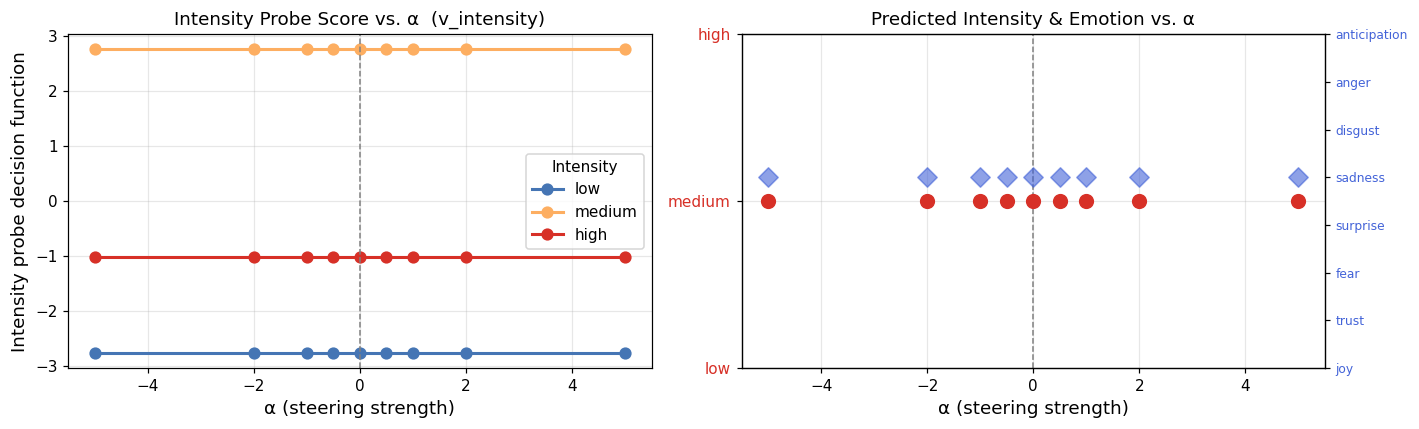

In [39]:
SWEEP_BASE   = "I guess that was okay."
SWEEP_PROMPT = make_prompt(SWEEP_BASE)

sweep_rows = []

for alpha in ALPHA_GRID:
    # ── Generation ────────────────────────────────────────────────────────────
    if alpha == 0:
        h    = get_hidden_state(SWEEP_PROMPT)
        text = generate_steered(SWEEP_BASE, steer_vec=None)
    else:
        h    = get_hidden_state_steered(SWEEP_PROMPT, v_intensity, alpha)
        text = generate_steered(SWEEP_BASE, steer_vec=v_intensity, alpha=alpha)

    # ── Probe ─────────────────────────────────────────────────────────────────
    h32    = h.reshape(1, -1).astype(np.float32)
    df_int = int_clf.decision_function(int_scaler.transform(h32))[0]   # (N_INT,)
    df_emo = emo_clf.decision_function(emo_scaler.transform(h32))[0]   # (N_EMO,)

    row = {
        "alpha":          alpha,
        "text":           text,
        "pred_intensity": INTENSITY_ORDER[int(int_clf.predict(int_scaler.transform(h32))[0])],
        "pred_emotion":   EMOTION_ORDER[int(emo_clf.predict(emo_scaler.transform(h32))[0])],
    }
    for ii, intens in enumerate(INTENSITY_ORDER):
        row[f"df_{intens}"] = float(df_int[ii])
    sweep_rows.append(row)

    # ── Free KV cache / Python temporaries between iterations ─────────────────
    del h, h32, df_int, df_emo
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sweep_df = pd.DataFrame(sweep_rows)

# ── Print table ───────────────────────────────────────────────────────────────
print(f"Sweep: v_intensity on '{SWEEP_BASE}'\n")
cols_show = ["alpha", "pred_emotion", "pred_intensity"] + [f"df_{i}" for i in INTENSITY_ORDER]
print(sweep_df[cols_show].to_string(index=False, float_format="{:.3f}".format))

# ── Plot: decision function scores vs alpha ───────────────────────────────────
int_colors = {"low": "#4575b4", "medium": "#fdae61", "high": "#d73027"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for intens in INTENSITY_ORDER:
    ax.plot(sweep_df["alpha"], sweep_df[f"df_{intens}"], "o-",
            color=int_colors[intens], label=intens, linewidth=2, markersize=7)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("α (steering strength)", fontsize=12)
ax.set_ylabel("Intensity probe decision function", fontsize=12)
ax.set_title("Intensity Probe Score vs. α  (v_intensity)", fontsize=12)
ax.legend(title="Intensity"); ax.grid(True, alpha=0.3)

ax = axes[1]
pred_to_y     = {intens: i for i, intens in enumerate(INTENSITY_ORDER)}
pred_to_y_emo = {emo: i for i, emo in enumerate(EMOTION_ORDER)}
ax.scatter(sweep_df["alpha"],
           [pred_to_y[p] for p in sweep_df["pred_intensity"]],
           c="#d73027", s=80, label="pred intensity", zorder=3)
ax2 = ax.twinx()
ax2.scatter(sweep_df["alpha"],
            [pred_to_y_emo[p] for p in sweep_df["pred_emotion"]],
            c="#4363d8", s=80, marker="D", label="pred emotion", zorder=3, alpha=0.6)
ax.set_yticks(range(N_INT)); ax.set_yticklabels(INTENSITY_ORDER, color="#d73027")
ax2.set_yticks(range(N_EMO)); ax2.set_yticklabels(EMOTION_ORDER, color="#4363d8", fontsize=8)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("α (steering strength)", fontsize=12)
ax.set_title("Predicted Intensity & Emotion vs. α", fontsize=12)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR / "alpha_sweep_v_intensity.png", bbox_inches="tight")
plt.show()


## 10. Alpha Grid Sweep — All Emotions & Intensities

Sweep `alpha` across `ALPHA_GRID` for **every** steering vector on a single base sentence.

Two sub-tables:
- **Emotion steering** (`v_emotion[e]`): one column per emotion, rows = alpha values
- **Intensity steering** (global `v_intensity` + per-emotion `v_emotion_intensity[e]`): same layout

Columns are truncated for readability; set `pd.set_option("display.max_colwidth", N)` to expand.

In [40]:
## ── 10a. Emotion steering sweep ─────────────────────────────────────────────
GRID_BASE = "I guess that was okay."
_baseline_text = generate_steered(GRID_BASE, steer_vec=None)

print(f"Base sentence : '{GRID_BASE}'")
print(f"Alpha grid    : {ALPHA_GRID}\n")

# Pre-generate texts: alpha × emotion
_emo_rows = []
for alpha in ALPHA_GRID:
    row = {"alpha": alpha}
    for emo in TARGET_EMOTIONS:
        if alpha == 0:
            row[emo] = _baseline_text
        else:
            ei = EMOTION_ORDER.index(emo)
            row[emo] = generate_steered(GRID_BASE, steer_vec=v_emotion[ei], alpha=alpha)
    _emo_rows.append(row)

emo_grid_df = pd.DataFrame(_emo_rows).set_index("alpha")

print("=== Emotion steering (v_emotion[e]) ===")
pd.set_option("display.max_colwidth", 55)
display(emo_grid_df)


Base sentence : 'I guess that was okay.'
Alpha grid    : [-5, -2, -1, -0.5, 0, 0.5, 1, 2, 5]

=== Emotion steering (v_emotion[e]) ===


,joy,trust,fear,surprise,sadness,disgust,anger,anticipation
alpha,,,,,,,,
-5.0,"It was a decent experience, but I'm still left with...","I was expecting so much more from that experience, ...","It was a decent experience, nothing particularly me...","It was a decent experience, but it could have been ...","I suppose that was somewhat satisfying, but it didn...","It was a decent experience, but it had its moments ...","It was a decent experience, but it didn't quite liv...","I suppose it was just passable, but I'm not exactly..."
-2.0,"It was a decent experience, but it didn't quite liv...","I suppose it was a decent effort, but it didn't qui...","It was a decent experience, nothing particularly me...","It was a decent experience, but it could have been ...","It was a decent experience, I suppose.","It was a decent experience, nothing particularly me...","It was a decent experience, but it didn't quite liv...","I suppose it was somewhat satisfactory, but I was e..."
-1.0,"It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it could have been ...","It was a decent experience, but it didn't exactly b...","It was a decent experience, but it could have been ...","It was a decent experience, but it could have been ...","It was a decent experience, but it could have been ..."
-0.5,"It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it could have been ...","It was a decent experience, but it didn't exactly b...","It was a decent experience, but it could have been ...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv..."
0.0,"It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv..."
0.5,"It was a decent experience, but it could have been ...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv..."
1.0,"It was a decent experience, but it could have been ...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it could have been ...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't exactly b...","It was a decent experience, but I'm not exactly thr...","It was a decent experience, but it didn't quite liv..."
2.0,"It was a decent experience, nothing particularly me...","It was a decent experience, but it didn't particula...","It was a decent experience, but I'm not entirely su...","I suppose that was somewhat satisfying, but it didn...","It was a decent experience, but it could have been ...","It was a decent experience, but I'm not exactly thr...","It was a decent experience, but I'm not exactly thr...","It was a decent experience, but it didn't quite liv..."
5.0,"It was a decent experience, but it could have been ...","It was a decent experience, but it didn't particula...",I suppose it was somewhat satisfactory.,"I was a bit underwhelmed, but I suppose it was a de...","It was a decent experience, but it could h

In [41]:
for alpha, row in emo_grid_df.iterrows():
    print(f"\n{'─'*70}")
    print(f"  α = {alpha}")
    print(f"{'─'*70}")
    for emo in TARGET_EMOTIONS:
        print(f"  [{emo:>14}]  {row[emo]}")


──────────────────────────────────────────────────────────────────────
  α = -5.0
──────────────────────────────────────────────────────────────────────
  [           joy]  It was a decent experience, but I'm still left with a lingering sense of disappointment.
  [         trust]  I was expecting so much more from that experience, but I guess it was just a mediocre attempt at trying to be something it wasn't.
  [          fear]  It was a decent experience, nothing particularly memorable or life-changing.
  [      surprise]  It was a decent experience, but it could have been better.
  [       sadness]  I suppose that was somewhat satisfying, but it didn't exactly blow me away.
  [       disgust]  It was a decent experience, but it had its moments of pleasantness.
  [         anger]  It was a decent experience, but it didn't quite live up to my expectations.
  [  anticipation]  I suppose it was just passable, but I'm not exactly thrilled about it.

──────────────────────────────────────

In [42]:
## ── 10b. Intensity steering sweep (global + per-emotion) ─────────────────────

# Build column: global v_intensity first, then per-emotion v_emotion_intensity[e]
_int_rows = []
for alpha in ALPHA_GRID:
    row = {"alpha": alpha}
    # global intensity
    if alpha == 0:
        row["v_int (global)"] = _baseline_text
    else:
        row["v_int (global)"] = generate_steered(GRID_BASE, steer_vec=v_intensity, alpha=alpha)
    # emotion-specific intensity
    for emo in TARGET_EMOTIONS:
        ei = EMOTION_ORDER.index(emo)
        col = f"v_int[{emo}]"
        if alpha == 0:
            row[col] = _baseline_text
        else:
            row[col] = generate_steered(GRID_BASE, steer_vec=v_emotion_intensity[ei], alpha=alpha)
    _int_rows.append(row)

int_grid_df = pd.DataFrame(_int_rows).set_index("alpha")

print("=== Intensity steering (global + v_emotion_intensity[e]) ===")
pd.set_option("display.max_colwidth", 55)
display(int_grid_df)


=== Intensity steering (global + v_emotion_intensity[e]) ===


,v_int (global),v_int[joy],v_int[trust],v_int[fear],v_int[surprise],v_int[sadness],v_int[disgust],v_int[anger],v_int[anticipation]
alpha,,,,,,,,,
-5.0,"It was somewhat satisfactory, I suppose.",It was somewhat unimpressive.,"It was somewhat unimpressive, but I suppose it was ...","It was a decent experience, nothing particularly me...","It was a decent experience, nothing particularly me...","It was a decent experience, nothing particularly me...","It was a decent experience, nothing particularly me...","It was a decent experience, nothing particularly me...","It was a decent experience, but it didn't really le..."
-2.0,"It was a decent experience, I suppose.","It was a decent experience, I suppose.","It was a decent experience, I suppose.","It was a decent experience, nothing particularly me...","It was a decent experience, nothing particularly me...","It was a decent experience, nothing particularly me...","It was a decent experience, nothing particularly me...","It was a decent experience, nothing particularly me...","It was a decent experience, but it didn't really le..."
-1.0,"It was a decent experience, but it didn't really le...","It was a decent experience, I suppose.","It was a decent experience, but it didn't really le...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't really le...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't really le..."
-0.5,"It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv..."
0.0,"It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv..."
0.5,"It was a decent experience, but it could have been ...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it could have been ...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it could have been ...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it could have been ..."
1.0,"It was a decent experience, but it could have been ...","It was a decent experience, but I'm not blown away.","It was a decent experience, but it could have been ...","It was a decent experience, but it didn't quite liv...","It was a decent experience, but I'm not blown away.","It was a decent experience, but it didn't quite liv...","It was a decent experience, but it could have been ...","It was a decent experience, but I'm not blown away.","It was a decent experience, but it could have been ..."
2.0,"I suppose it was a decent effort, but it left me fe...","I suppose that was a decent effort, but it left me ...","It was a decent experience, but I'm not entirely sa...","I suppose it was a decent effort, but it left me fe...","I suppose that was a decent effort, but it left me ...","It was a decent experience, but it left me feeling ..."

In [43]:
for alpha, row in int_grid_df.iterrows():
    print(f"\n{'─'*70}")
    print(f"  α = {alpha}")
    print(f"{'─'*70}")
    print(f"  [{'v_int (global)':>20}]  {row['v_int (global)']}")
    for emo in TARGET_EMOTIONS:
        col = f"v_int[{emo}]"
        print(f"  [{col:>20}]  {row[col]}")


──────────────────────────────────────────────────────────────────────
  α = -5.0
──────────────────────────────────────────────────────────────────────
  [      v_int (global)]  It was somewhat satisfactory, I suppose.
  [          v_int[joy]]  It was somewhat unimpressive.
  [        v_int[trust]]  It was somewhat unimpressive, but I suppose it was passable.
  [         v_int[fear]]  It was a decent experience, nothing particularly memorable.
  [     v_int[surprise]]  It was a decent experience, nothing particularly memorable.
  [      v_int[sadness]]  It was a decent experience, nothing particularly memorable.
  [      v_int[disgust]]  It was a decent experience, nothing particularly memorable.
  [        v_int[anger]]  It was a decent experience, nothing particularly memorable.
  [ v_int[anticipation]]  It was a decent experience, but it didn't really leave a lasting impression on me.

──────────────────────────────────────────────────────────────────────
  α = -2.0
──────────────

## 11. Results Summary & CSV Export

Compile all steering outputs into a single DataFrame and save to CSV.

In [ ]:
# ── Compile qualitative results ───────────────────────────────────────────────
all_qual_rows = []

# Emotion steering (section 5)
for _, row in emo_steer_df.iterrows():
    all_qual_rows.append({
        "experiment":  "emotion_steering",
        "steer_vec":   row["emotion"],
        "alpha":       ALPHA_DEFAULT if row["emotion"] != "baseline" else 0.0,
        "steer_layer": STEER_LAYER,
        "prompt":      row["prompt"],
        "output":      row["output"],
    })

# Intensity steering (section 6)
for _, row in int_steer_df.iterrows():
    alpha = ALPHA_DEFAULT if "+" in row["direction"] else (-ALPHA_DEFAULT if "-" in row["direction"] else 0.0)
    all_qual_rows.append({
        "experiment":  "intensity_steering",
        "steer_vec":   row["direction"],
        "alpha":       alpha,
        "steer_layer": STEER_LAYER,
        "prompt":      row["prompt"],
        "output":      row["output"],
    })

# Emotion-specific intensity steering (section 7)
for _, row in emo_int_df.iterrows():
    alpha = ALPHA_DEFAULT if "+" in row["vector"] else 0.0
    all_qual_rows.append({
        "experiment":  "emo_specific_intensity",
        "steer_vec":   row["vector"],
        "alpha":       alpha,
        "steer_layer": STEER_LAYER,
        "prompt":      row["prompt"],
        "output":      row["output"],
    })

# Re-probe results (section 8)
probe_export = probe_df.copy()
probe_export["steer_layer"] = STEER_LAYER
probe_export["alpha"]       = probe_export["direction"].map(
    {"baseline": 0.0, "+v_intensity": ALPHA_DEFAULT, "-v_intensity": -ALPHA_DEFAULT}
)

# Alpha sweep (section 9)
sweep_export = sweep_df[["alpha", "pred_emotion", "pred_intensity", "text"]].copy()
sweep_export["experiment"] = "alpha_sweep_v_intensity"
sweep_export["prompt"]     = SWEEP_BASE

# ── Save all to CSV ───────────────────────────────────────────────────────────
qual_df = pd.DataFrame(all_qual_rows)
qual_df.to_csv(OUT_DIR / "steering_qualitative_results.csv", index=False)
probe_export.to_csv(OUT_DIR / "steering_probe_results.csv", index=False)
sweep_export.to_csv(OUT_DIR / "alpha_sweep_results.csv", index=False)

# Pairwise CAA results (sections 5b-i and 5b-ii)
pairwise_df["steer_layer"]        = STEER_LAYER
pairwise_df["alpha"]              = ALPHA_DEFAULT
pairwise_df.to_csv(OUT_DIR / "pairwise_allpairs_results.csv", index=False)

ovr_vs_pairwise_df["steer_layer"] = STEER_LAYER
ovr_vs_pairwise_df["alpha"]       = ALPHA_DEFAULT
ovr_vs_pairwise_df.to_csv(OUT_DIR / "pairwise_vs_ovr_results.csv", index=False)

print(f"Saved to: {OUT_DIR.resolve()}")
print(f"  steering_qualitative_results.csv  ({len(qual_df)} rows)")
print(f"  steering_probe_results.csv        ({len(probe_export)} rows)")
print(f"  alpha_sweep_results.csv           ({len(sweep_export)} rows)")
print(f"  pairwise_allpairs_results.csv     ({len(pairwise_df)} rows)")
print(f"  pairwise_vs_ovr_results.csv       ({len(ovr_vs_pairwise_df)} rows)")

# ── Summary table (no tabulate dependency) ────────────────────────────────────
print("\n\n=== SUMMARY: Intensity steering on 'I guess that was okay.' ===")
print(f"  alpha range: {min(ALPHA_GRID)} … {max(ALPHA_GRID)}")
print(f"  steer layer: {STEER_LAYER}")
print()
print(sweep_export[["alpha", "pred_emotion", "pred_intensity", "text"]].to_string(index=False))


Saved to: /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/steering
  steering_qualitative_results.csv  (72 rows)
  steering_probe_results.csv        (18 rows)
  alpha_sweep_results.csv           (9 rows)


=== SUMMARY: Intensity steering on 'I guess that was okay.' ===
  alpha range: -5 … 5
  steer layer: 13

 alpha pred_emotion pred_intensity                                                                                                                             text
  -5.0      sadness         medium                                                                                         It was somewhat satisfactory, I suppose.
  -2.0      sadness         medium                                                                                           It was a decent experience, I suppose.
  -1.0      sadness         medium                                               It was a decent experience, but it didn't really leave a lasting impression on me.
  -0.5      sa